
This notebook uses an **Economics Dataset** to demonstrate the implementation of **Multiple Linear Regression**. The goal is to predict the **Index Price** based on economic indicators such as **Interest Rate** and **Unemployment Rate**.

### Dataset Features

| Feature | Description |
|---------|-------------|
| **Year** | Year of observation |
| **Month** | Month of observation |
| **Interest_Rate** | Interest rate (%) |
| **Unemployment_Rate** | Unemployment rate (%) |
| **Index_Price** | Stock market index price (Target Variable) |

### Input and Output Variables

**Independent Variables (X):**
- Interest_Rate
- Unemployment_Rate

**Dependent Variable (y):**
- Index_Price



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df_index = pd.read_csv("/content/drive/MyDrive/AI New folder/economic_index.csv")

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
# Drop unnecessary columns which will not affect our prediction model in
df_index.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


Now we have 2 Independent Feature and 1 Dependent Feature

In [6]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


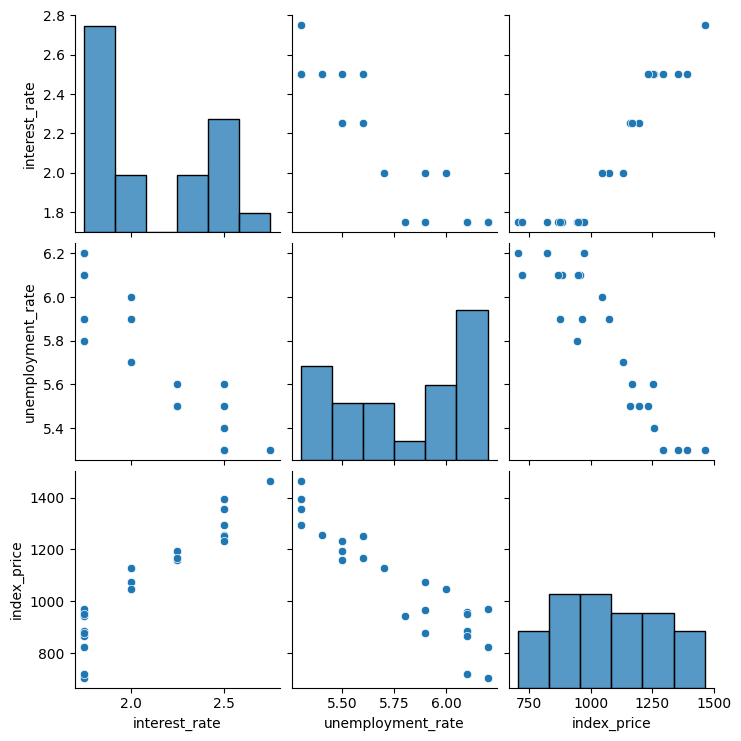

In [7]:
import seaborn as sns
sns.pairplot(df_index)

When we look at `df_index`, we can observe the relationships between the variables.

The **Index Price** and **Interest Rate** show a **positive linear relationship**. This means that as the interest rate increases, the index price also tends to increase.

On the other hand, the **Index Price** and **Unemployment Rate** have a **negative (inverse) relationship**. This means that when the unemployment rate increases, the index price generally decreases.

Similarly, **Interest Rate** and **Unemployment Rate** also have a **negative correlation**, indicating that as one variable increases, the other tends to decrease.

We can verify these relationships using the `correlation matrix`.


In [8]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000



The correlation matrix will show:

* **Interest Rate ↔ Index Price:** Positive correlation (+)
* **Unemployment Rate ↔ Index Price:** Negative correlation (−)
* **Interest Rate ↔ Unemployment Rate:** Negative correlation (−)

### Interpretation

* If the **interest rate increases**, the **index price** generally increases.
* If the **unemployment rate increases**, the **index price** generally decreases.

Since both **Interest Rate** and **Unemployment Rate** are strongly related to the target variable (**Index Price**), we will use these two features to build a **Multiple Linear Regression** model.


# **Visualizing the Relationships**

**1. Interest Rate vs Unemployment Rate**

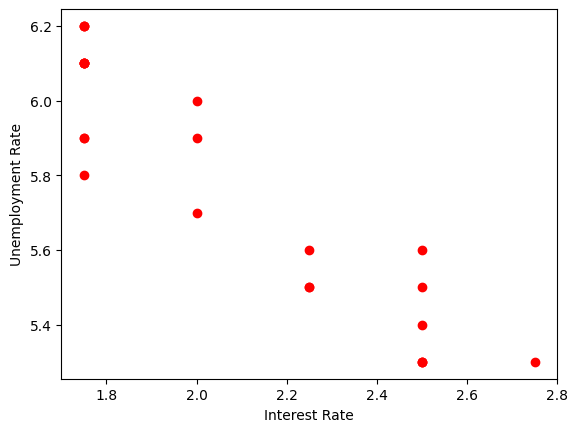

In [9]:
plt.scatter(
    df_index["interest_rate"],
    df_index["unemployment_rate"],
    color="red"
)

plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")
plt.show()

If, we create another scatter plot between Interest Rate and Index Price.

This plot shows a positive correlation, meaning that higher interest rates are generally associated with higher index prices.

# **Divide Dataset into Independent and Dependent Features**

In [10]:
X = df_index[['interest_rate','unemployment_rate']]
y = df_index['index_price']

Perffered way :
```
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]
```




In [11]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [12]:
y.head()

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256


# **Slipt Dataset into train and Test**

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

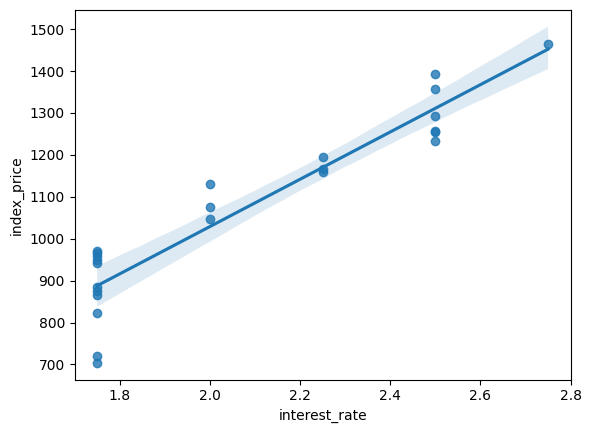

In [14]:
import seaborn as sns

# Interest Rate vs Index Price
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

### Output Interpretation

* Each dot represents one data point.
* The blue line is the **best-fit linear regression line**.
* The shaded region around the line is the **95% confidence interval** for the regression estimate.
* Since the points are close to the regression line, the linear relationship appears to be fairly strong, suggesting relatively small prediction errors.


This plot is extremely useful for regression analysis because it not only visualizes the data points but also fits a best-fit linear regression line, making it easier to understand the relationship between the variables.

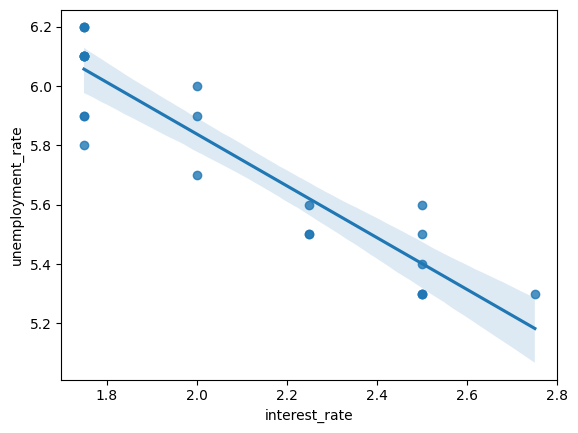

In [15]:
# Interest Rate vs Unemployment Rate
sns.regplot(
    x=df_index["interest_rate"],
    y=df_index["unemployment_rate"]
)
plt.show()

### Output Interpretation

Here, the regression line slopes downward, indicating a **negative (inverse) relationship**.

This means:

* As the **Interest Rate** increases,
* The **Unemployment Rate** generally decreases.

Again, the fitted regression line helps us visualize the overall trend in the data.


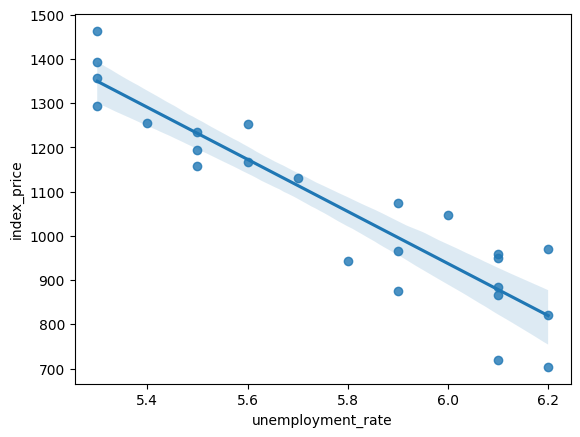

In [16]:
# Unemployment Rate vs Index Price
sns.regplot(
    x=df_index["unemployment_rate"],
    y=df_index["index_price"]
)
plt.show()

### Output Interpretation

This plot also shows a **negative linear relationship**.

It indicates that:

* Higher unemployment rates are generally associated with lower index prices.


## **What Does the Shaded Region Mean?**

The shaded area around the regression line represents the **confidence interval** (95% by default).

It indicates the uncertainty in estimating the true regression line.

* A **narrow confidence interval** suggests that the regression estimate is more reliable.
* A **wider confidence interval** indicates greater uncertainty.

> **Note:** The shaded region is **not** the prediction error of individual data points. It represents the confidence in the estimated regression line.

---

## Why Use `regplot()`?

`regplot()` is useful because it allows you to:

* Visualize the relationship between two variables.
* Check whether the relationship is approximately linear.
* Observe whether the slope is positive or negative.
* Identify potential outliers.
* Get a quick understanding of how well a linear model might fit the data.

---

## Limitation of `regplot()`

`regplot()` can only visualize the relationship between **two variables at a time**:

* One variable on the **x-axis**
* One variable on the **y-axis**

It cannot directly visualize relationships involving three or more features. For multiple features, other visualization techniques or machine learning models are used.


# **Feature Scaling**

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [21]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

# **Model Training**

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
regression = LinearRegression()

# **Train the Model**

In [24]:
regression.fit(X_train,y_train)

LinearRegression()

Here, the model learns the relationship between the input features (X_train) and the target variable (y_train).

# **Introducing Cross Validation**


Cross Validation is a model evaluation technique that helps us estimate how well our model is likely to perform on unseen data. Instead of relying on a single train-validation split, it evaluates the model multiple times using different portions of the training dataset.

Scikit-learn provides the `cross_val_score()` function for this purpose.

## Using `cross_val_score()`

The basic syntax is:

```python
validation_scores = cross_val_score(
    estimator=regression,
    X=X_train,
    y=y_train,
    scoring="neg_mean_squared_error",
    cv=5
)
```


## Why Use Cross Validation?

Cross Validation provides several advantages:

* Makes better use of the available training data.
* Produces a more reliable estimate of model performance.
* Reduces the chance of overfitting to a single train-validation split.
* Helps compare different machine learning models fairly.
* Is commonly used for model selection and hyperparameter tuning.

> **Important:** Cross Validation is performed **only on the training data**. The test dataset is kept completely separate and is used only once after the model has been finalized to evaluate its performance on unseen data.


In [25]:
from sklearn.model_selection import cross_val_score
validation_scores = cross_val_score(regression,X_train,y_train,
                                    scoring='neg_mean_squared_error',cv=3)


### Understanding the Parameters

### `estimator`

The estimator is simply the machine learning model that you want to evaluate.

In our case:

```python
estimator = regression
```

---

### `X`

The feature matrix used for training.

```python
X = X_train
```

---

### `y`

The target variable corresponding to the training data.

```python
y = y_train
```

---

### `scoring`

This parameter specifies the evaluation metric.

For regression problems, Scikit-learn supports several scoring metrics, such as:

* `r2`
* `neg_mean_squared_error`
* `neg_mean_absolute_error`
* `neg_root_mean_squared_error`

Here, we use:

```python
scoring="neg_mean_squared_error"
```

Scikit-learn returns the **negative** value because its optimization framework assumes that **higher scores are better**. Since Mean Squared Error (MSE) is a quantity we want to **minimize**, Scikit-learn reports its negative value instead.

A score closer to **zero** (less negative) indicates better model performance.

---

## Understanding the `cv` Parameter

The `cv` parameter specifies the number of folds used for Cross Validation.

For example:

```python
cv=5
```

means **5-Fold Cross Validation**.

To understand this more easily, let's assume:

* Total dataset = **1000 records**
* After Train-Test Split:

  * Training data = **900 records**
  * Test data = **100 records**

The **test dataset remains untouched** throughout model training and validation. It is only used once at the very end to evaluate the final model.

Cross Validation is performed **only on the training dataset**.

---

## Example: 5-Fold Cross Validation

Suppose the training dataset contains **900 records**.

With:

```python
cv = 5
```

the training data is divided into **5 equal parts (folds)**.

Each fold contains:

```
900 ÷ 5 = 180 records
```

During Cross Validation, the model is trained and validated five times.

### Fold 1

* Validation Data → Records **1–180**
* Training Data → Remaining **720 records**

### Fold 2

* Validation Data → Records **181–360**
* Training Data → Remaining **720 records**

### Fold 3

* Validation Data → Records **361–540**
* Training Data → Remaining **720 records**

### Fold 4

* Validation Data → Records **541–720**
* Training Data → Remaining **720 records**

### Fold 5

* Validation Data → Records **721–900**
* Training Data → Remaining **720 records**

In every iteration:

* One fold acts as the **validation set**.
* The remaining four folds are used for **training**.
* This process continues until every fold has served as the validation set exactly once.

Finally, the evaluation scores from all five folds are averaged to obtain a more reliable estimate of the model's performance.


In [26]:
validation_scores

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

### **Evaluating the Model Using Cross Validation**

**Cross Validation** returns one evaluation score for each fold.

Since we selected:

```python
scoring="neg_mean_squared_error"
```

the score returned for each fold will be the **Negative Mean Squared Error (Negative MSE)**.

For example, if we use:

```python
cv = 5
```

Cross Validation evaluates the model five times and returns five MSE values:

* MSE₁
* MSE₂
* MSE₃
* MSE₄
* MSE₅

Because we selected **`neg_mean_squared_error`**, all these values will be **negative**.

> **Why are the values negative?**
>
> Scikit-learn assumes that **higher scores indicate better performance**. Since Mean Squared Error (MSE) is a metric that should be **minimized**, Scikit-learn returns its negative value so that larger (less negative) scores represent better models.

The closer the Negative MSE is to **zero**, the better the model performs.

In [27]:
np.mean(validation_scores)

np.float64(-5914.828180162386)

### **Calculating the Average Cross Validation Score**

After Cross Validation, we can compute the average score across all folds.



To calculate the mean score:

```python
import numpy as np

np.mean(validation_scores)
```

This gives the **average validation score**, providing a more reliable estimate of the model's performance than relying on a single train-validation split.

### **Cross Validation after Scaling (Data Leakage)**

Currently we do

```python
scaler.fit_transform(X_train)
```

and then

```python
cross_val_score(regression, X_train, y_train, ...)
```

This works, but it introduces **data leakage** because the scaler has already seen the entire training set before CV splits it.

The better production approach is

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    scoring="neg_mean_squared_error",
    cv=3
)
```

# **Making Predictions**
Once the model has been trained and validated, the next step is to make predictions on the test dataset.

In [28]:
y_pred = regression.predict(X_test)

Here:

* `X_test` contains unseen feature values.
* `y_pred` contains the predicted target values generated by the model.


In [29]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

### **Evaluating the Model Performance**

Now that we have the predictions, we can calculate different evaluation metrics.

For regression problems, the commonly used metrics are:

* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)
* R² Score
* Adjusted R² Score

For example:



* **R² = 0.75** means the model explains approximately **75% of the variance** in the target variable.
* **Adjusted R² = 0.59** accounts for the number of input features and penalizes unnecessary variables.

Since Adjusted R² penalizes additional features, it is generally **less than or equal to** the R² score.


In [66]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [67]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
print("Mean Squared Error: ",mse)
print("Mean Absolute Error: ",mae)
print("Root Mean Squared Error: ",np.sqrt(mse))

Mean Squared Error:  5793.762887712569
Mean Absolute Error:  59.935781523235484
Root Mean Squared Error:  76.11677139574805


In [68]:
# Accuracy of the model R Squared and Adjusted R Squared
from sklearn.metrics import r2_score

In [69]:
r2_score = regression.score(X_test,y_test)
print("R2 Score: ",r2_score)

R2 Score:  0.8278978091457145


In [70]:
# Adjusted R Squared
1 - (1-r2_score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7131630152428576

## **Checking Linear Regression Assumptions**

Performance metrics alone do not tell us whether a Linear Regression model is appropriate.

We also need to verify that the model satisfies the assumptions of Linear Regression.

**Assumption 1: Predicted Values vs Actual Values**

First, plot the actual values against the predicted values.

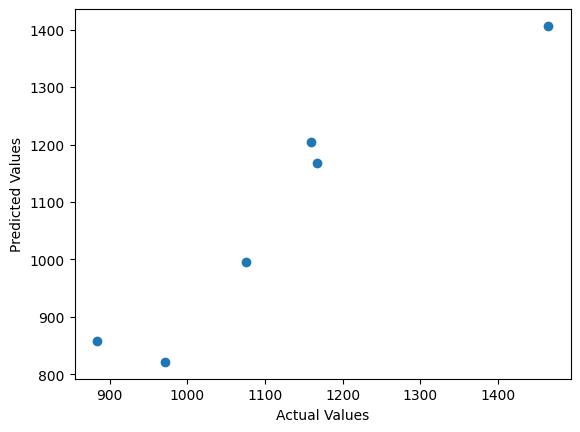

In [30]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

**Interpretation**

If the predicted values closely follow the actual values and exhibit a strong linear relationship, it indicates that the model has learned the underlying pattern reasonably well.





**Assumption 2: Residual Analysis**

Residuals are simply the prediction errors.

They are calculated as:

In [31]:
residuals = y_test - y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64



**Assumption 3: Distribution of Residuals**

Visualize the distribution of the residuals.

```python
sns.histplot(residuals, kde=True)
plt.show()
```

> **Note:** `sns.distplot()` has been deprecated. Use `sns.histplot(..., kde=True)` or `sns.displot()` in newer versions of Seaborn.

***Interpretation***

A good Linear Regression model should have residuals that are approximately **normally distributed**.

The histogram should resemble a **bell-shaped (Gaussian) curve** centered around zero.

This suggests that the model's prediction errors are random rather than systematic.

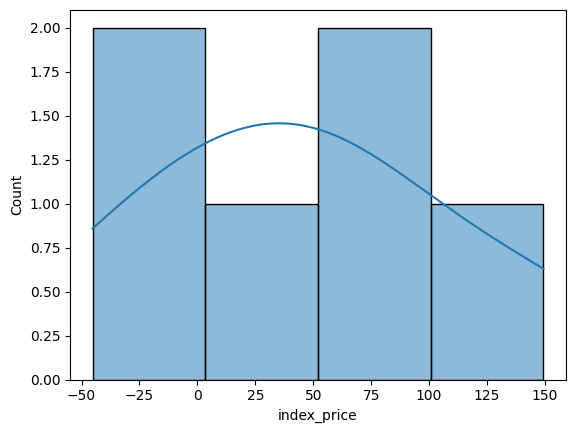

In [32]:
sns.histplot(residuals, kde=True)
plt.show()


**Assumption 4: Residuals vs Predicted Values**

Finally, plot the residuals against the predicted values.



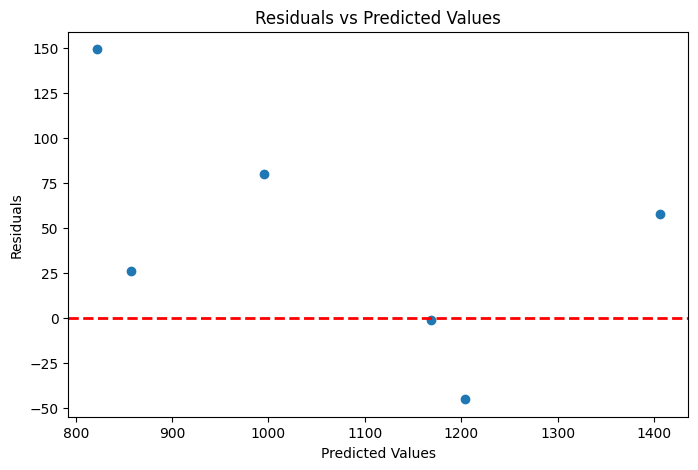

In [35]:
# Residuals vs Predicted Values
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2) # It makes the residual analysis much clearer.

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

**Interpretation**

This plot helps identify whether any patterns exist in the prediction errors.

For a well-fitted Linear Regression model:

* Residuals should be randomly scattered around zero.
* There should be **no clear pattern**.
* The spread of residuals should remain roughly constant across all predicted values.

A random scatter indicates that the model has captured the relationship in the data well.

### **What If a Pattern Appears?**

If the residual plot shows a systematic pattern (such as a curve or funnel shape), it may indicate that one or more assumptions of Linear Regression have been violated.

Common patterns include:

* A curved pattern → The relationship may be non-linear.
* A funnel shape → The variance of the errors is not constant (heteroscedasticity).
* Clusters or trends → Important variables may be missing, or the model may not fit the data adequately.

In such cases, a Linear Regression model may not be the best choice, and further feature engineering or a different model may be required.


## **OLS Linear Regression**

In [36]:
import statsmodels.api as sm

In [76]:
# This is incorrect if you want results comparable to LinearRegression() from scikit-learn.
model = sm.OLS(y_train,X_train).fit()

In [37]:
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            index_price   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     69.88
Date:                Tue, 07 Jul 2026   Prob (F-statistic):           2.50e-08
Time:                        08:18:02   Log-Likelihood:                -100.85
No. Observations:                  18   AIC:                             207.7
Df Residuals:                      15   BIC:                             210.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1053.4444     16.941     62.183      0.000    1017.336    1089.553
x1            88.2728     42.263      2.089      0.054      -1.810     178.355
x2          -116.2572     42.263     -2.751      0.015    -206.340     -26.175
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   1.804
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Reason

* LinearRegression() fits an intercept by default.
* statsmodels.OLS() does not unless you add it manually



## **Verifying the Coefficients Using OLS**

Finally, we compare the coefficients obtained from **Scikit-learn's `LinearRegression`** with those from **Ordinary Least Squares (OLS)** using the `statsmodels` library.

```python
print(regression.coef_)
```

Suppose the output is:

```
[88.2728, 116.2572]
```

If the coefficients produced by the OLS model are nearly identical, it confirms that both implementations have learned the same linear relationship.

This consistency increases our confidence that the model has been trained correctly.


